# ANALISI RISULTATI 2022 HS4 (file parquet)

### FILE PARQUET:
\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\products.parquet

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet(r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\products.parquet")

# 1) VARIATION IN PRODUCT COMPLEXITY

## HS4 

## a) Ranking variation (integrare i risultati in products.parquet)

In [3]:
df["rank_complexity"] = (
    df["complexity"]
    .rank(ascending=False)
    .astype(int)
)
df["rank_total"] = (
    df["total_complexity"]
    .rank(ascending=False)
    .astype(int)
)

df["rank_shift"] = (
    df["rank_complexity"]
    - df["rank_total"]
    .astype(int)
)
df.to_parquet(r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\products_2.parquet")

In [4]:
final_table = (
    df[
        [
            "product",
            "description",
            "rank_shift"
        ]
    ]
    .sort_values(
        "rank_shift",
        ascending=False
    )
    .reset_index(drop=True)
)
print(final_table)

     product                                        description  rank_shift
0       8901  Cruise ships, excursion boats and similar vess...        1131
1       8903                           Yachts and other vessels        1090
2       8802     Aeroplanes and other aircraft, except unmanned        1062
3       8907                                              Rafts        1051
4       4201                               Saddlery and harness        1007
...      ...                                                ...         ...
1184    2810                                    Oxides of boron        -736
1185    3504                     Peptones and their derivatives        -742
1186    2528  Natural borates and concentrates thereof (whet...        -742
1187    1204                                          Oil seeds        -743
1188    2813                                  Carbon disulphide        -778

[1189 rows x 3 columns]


## b) Value variation (integrare i risultati in products.parquet)

In [5]:
df["delta_complexity"] = (
    df["total_complexity"]
    - df["complexity"]
)

In [6]:
full_delta_table = (
    df[
        [
            "product",
            "description",
            "delta_complexity"
        ]
    ]
    .sort_values(
        "delta_complexity",
        ascending=False
    )
    .reset_index(drop=True)
)
print (full_delta_table)

     product                                        description  \
0       8708                                      Vehicle parts   
1       8807                            Aircraft and spacecraft   
2       8703                                           Vehicles   
3       8702                                           Vehicles   
4       8901  Cruise ships, excursion boats and similar vess...   
...      ...                                                ...   
1184    9012        Microscopes (excluding optical microscopes)   
1185    7218                                   Steel, stainless   
1186    8524  Flat panel display modules, whether or not inc...   
1187    8444                                  Textile machinery   
1188    2919                                             Esters   

      delta_complexity  
0             5.397537  
1             5.148813  
2             5.006997  
3             4.783414  
4             4.642605  
...                ...  
1184         -7.1025

## HS2

## a.a) Aggregate ranking variation (ok)

L' aggregazione viene fatta solo dopo aver fatto girare l algoritmo su dati HS4

In [7]:
df["HS2"] = (
    df["product"]
    .astype(str)
    .str.zfill(4)
    .str[:2]
)
hs2 = (
    df.groupby("HS2")
    .agg({
        "complexity":"mean",
        "total_complexity":"mean"
    })
    .reset_index()
)
hs2["rank_complexity"] = (
    hs2["complexity"]
    .rank(ascending=False)
    .astype(int)
)

hs2["rank_total"] = (
    hs2["total_complexity"]
    .rank(ascending=False)
    .astype(int)
)

hs2["rank_shift"] = (
    hs2["rank_complexity"]
    - hs2["rank_total"]
)
hs2_table = (
    hs2[
        [
            "HS2",
            "rank_complexity",
            "rank_total",
            "rank_shift"
        ]
    ]
    .sort_values(
        "rank_shift",
        ascending=False
    )
)

print(hs2_table)

   HS2  rank_complexity  rank_total  rank_shift
87  89               89           4          85
61  62               75           5          70
60  61               77          12          65
86  88               67           3          64
62  63               64           6          58
..  ..              ...         ...         ...
34  35               14          63         -49
74  75                5          56         -51
28  29                3          54         -51
46  47               17          70         -53
27  28               12          72         -60

[92 rows x 4 columns]


## a.b) Average ranking variation (ok)

In [8]:
df["rank_complexity"] = (
    df["complexity"]
    .rank(ascending=False)
)

df["rank_total"] = (
    df["total_complexity"]
    .rank(ascending=False)
)

df["rank_shift"] = (
    df["rank_complexity"]
    - df["rank_total"]
)
hs2_shift = (
    df.groupby("HS2")
    ["rank_shift"]
    .mean()
    .reset_index()
)
hs2_table = (
    hs2_shift
    .sort_values(
        "rank_shift",
        ascending=False
    )
    .reset_index(drop=True)
)

display(hs2_table)

,HS2,rank_shift
0,89,957.000000
1,62,737.235294
2,61,667.235294
3,88,549.500000
4,63,547.600000
...,...,...
87,47,-433.857143
88,28,-454.940000
89,29,-460.380952
90,45,-494.750000


# 2) CORRELATIONS

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

## a) Intrinsic complexity vs complexity 

### a.a) Value

Pearson correlation  : 0.9549
Spearman correlation : 0.9595


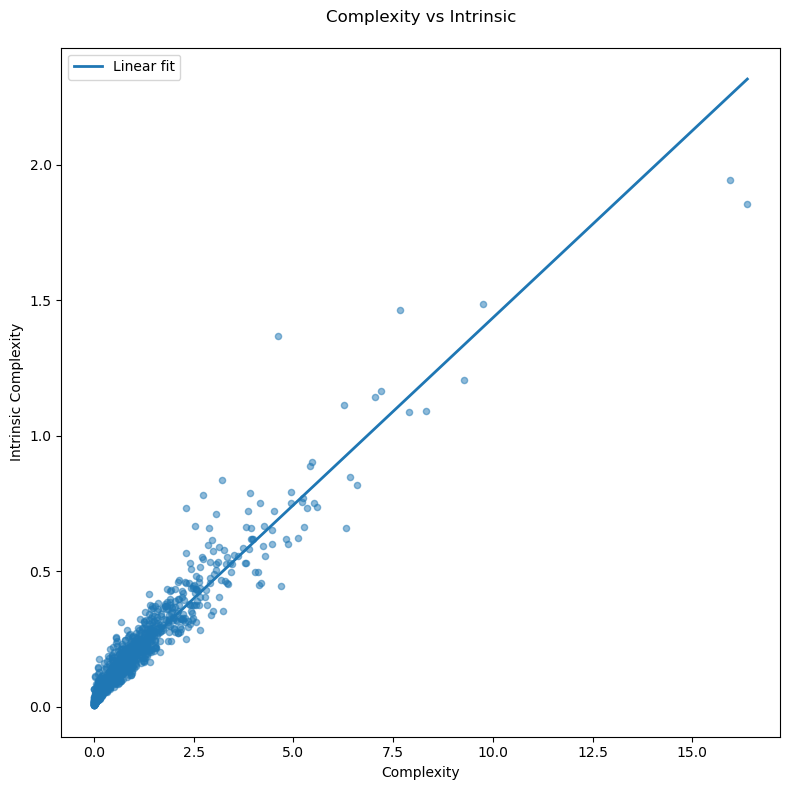

In [10]:
x = df["complexity"]
y = df["intrinsic_complexity"]

pearson = pearsonr(x, y)[0]
spearman = spearmanr(x, y)[0]
print(f"Pearson correlation  : {pearson:.4f}")
print(f"Spearman correlation : {spearman:.4f}")

plt.figure(figsize=(8,8))

plt.scatter(
    x,
    y,
    alpha=0.5,
    s=20
)

# regressione lineare
m, b = np.polyfit(x, y, 1)

xx = np.linspace(x.min(), x.max(), 200)

plt.plot(
    xx,
    m*xx + b,
    linewidth=2,
    label="Linear fit"
)


plt.xlabel("Complexity")
plt.ylabel("Intrinsic Complexity")

plt.title(
    f"Complexity vs Intrinsic\n"
   
)

plt.legend()
plt.tight_layout()

plt.show()

## a.b) Rank

In [11]:
from scipy.stats import spearmanr, kendalltau

Kendall correlation  : 0.8344
Spearman correlation : 0.9595


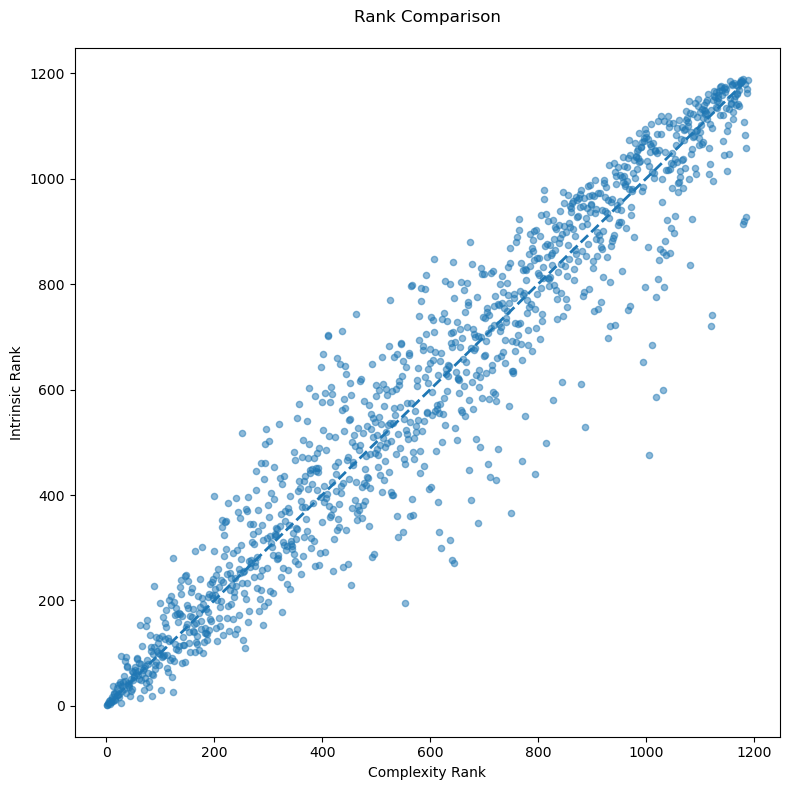

In [12]:
df["rank_complexity"] = (
    df["complexity"]
    .rank(ascending=False)
)

df["rank_intrinsic"] = (
    df["intrinsic_complexity"]
    .rank(ascending=False)
)

rho = spearmanr(
    df["rank_complexity"],
    df["rank_intrinsic"]
)[0]

tau = kendalltau(
    df["rank_complexity"],
    df["rank_intrinsic"]
)[0]

print(f"Kendall correlation  : {tau:.4f}")
print(f"Spearman correlation : {rho:.4f}")


plt.figure(figsize=(8,8))

plt.scatter(
    df["rank_complexity"],
    df["rank_intrinsic"],
    alpha=0.5,
    s=20
)

n = len(df)

plt.plot(
    [1,n],
    [1,n],
    "--",
    linewidth=2
)

plt.xlabel("Complexity Rank")
plt.ylabel("Intrinsic Rank")

plt.title(
    f"Rank Comparison\n"
    
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots\correlation_plot_2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## b) Total complexity vs complexity

Pearson correlation  : 0.1573
Spearman correlation : 0.3581


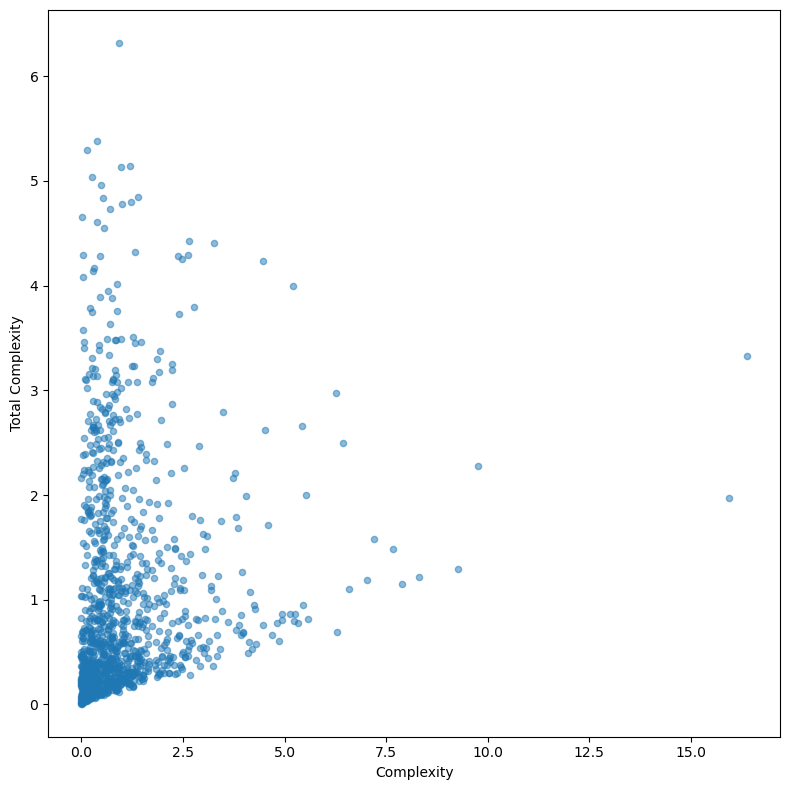

In [13]:
pearson = pearsonr(
    df["complexity"],
    df["total_complexity"]
)[0]

spearman = spearmanr(
    df["complexity"],
    df["total_complexity"]
)[0]

plt.figure(figsize=(8,8))

plt.scatter(
    df["complexity"],
    df["total_complexity"],
    alpha=0.5,
    s=20
)

plt.xlabel("Complexity")
plt.ylabel("Total Complexity")

print(f"Pearson correlation  : {pearson:.4f}")
print(f"Spearman correlation : {spearman:.4f}")

plt.tight_layout()
plt.savefig(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots\correlation_plot_3.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Complexity vs PCI

Pearson correlation  : -0.1996
Spearman correlation : -0.3991


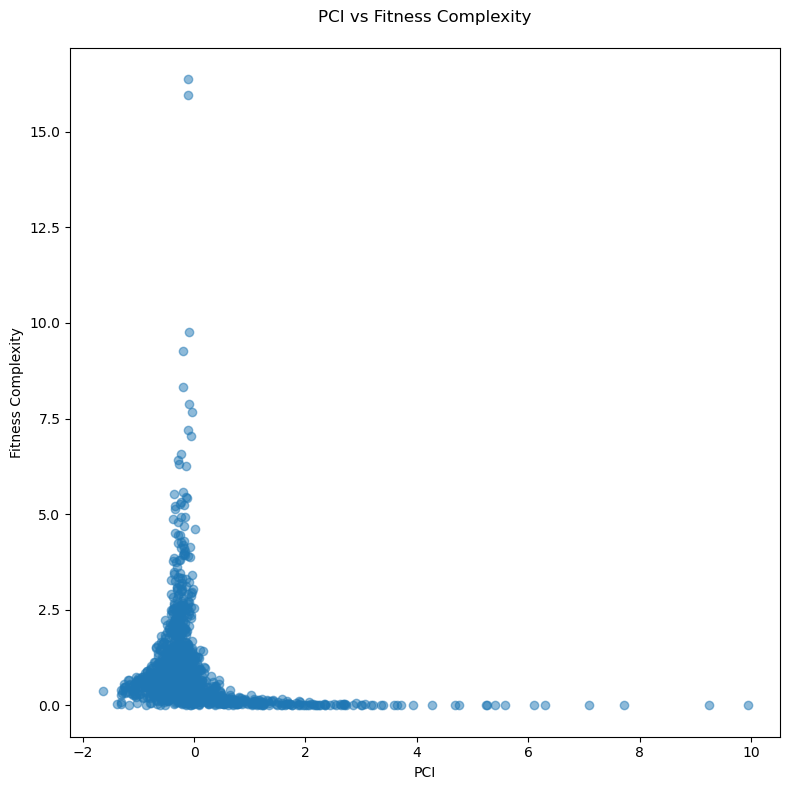

In [14]:
pearson = pearsonr(
    df["PCI"],
    df["complexity"]
)[0]

spearman = spearmanr(
    df["PCI"],
    df["complexity"]
)[0]

plt.figure(figsize=(8,8))

plt.scatter(
    df["PCI"],
    df["complexity"],
    alpha=0.5
)

plt.xlabel("PCI")
plt.ylabel("Fitness Complexity")

print(f"Pearson correlation  : {pearson:.4f}")
print(f"Spearman correlation : {spearman:.4f}")

plt.title(
    f"PCI vs Fitness Complexity\n"
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots\correlation_plot_4.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# PCI vs total complexity

Pearson correlation  : -0.3044
Spearman correlation : -0.4999


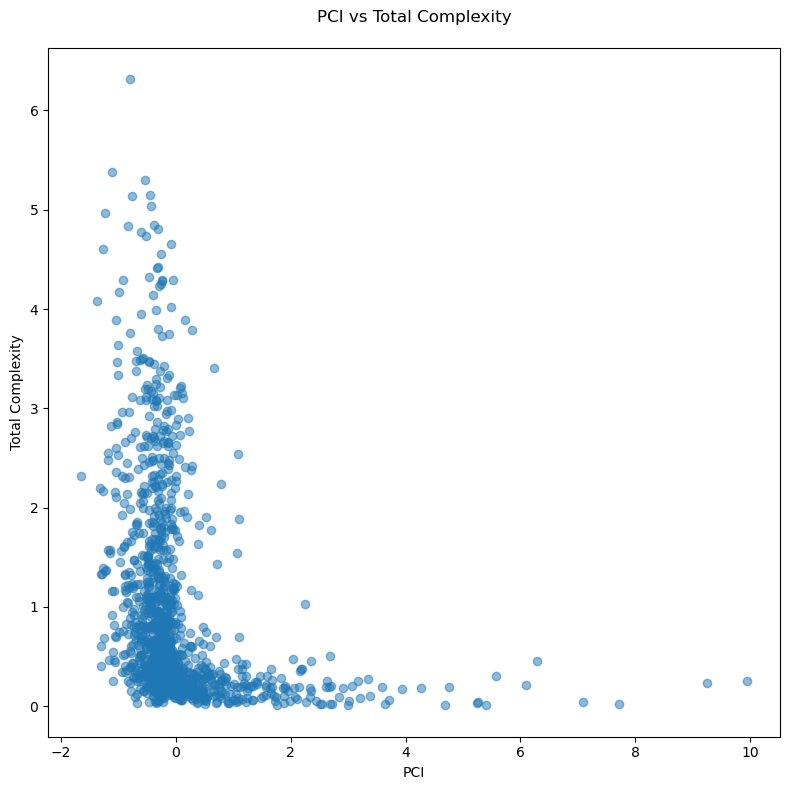

In [15]:
from scipy.stats import pearsonr,spearmanr

pearson = pearsonr(
    df["PCI"],
    df["total_complexity"]
)[0]

spearman = spearmanr(
    df["PCI"],
    df["total_complexity"]
)[0]
plt.figure(figsize=(8,8))

plt.scatter(
    df["PCI"],
    df["total_complexity"],
    alpha=0.5
)

plt.xlabel("PCI")

plt.ylabel(
    "Total Complexity"
)

print(f"Pearson correlation  : {pearson:.4f}")
print(f"Spearman correlation : {spearman:.4f}")

plt.title(
    f"PCI vs Total Complexity\n"
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots\correlation_plot_5.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 3) STUDIO DEGLI INPUT

## Numero di input vs total complexity

In [16]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

Pearson=0.898


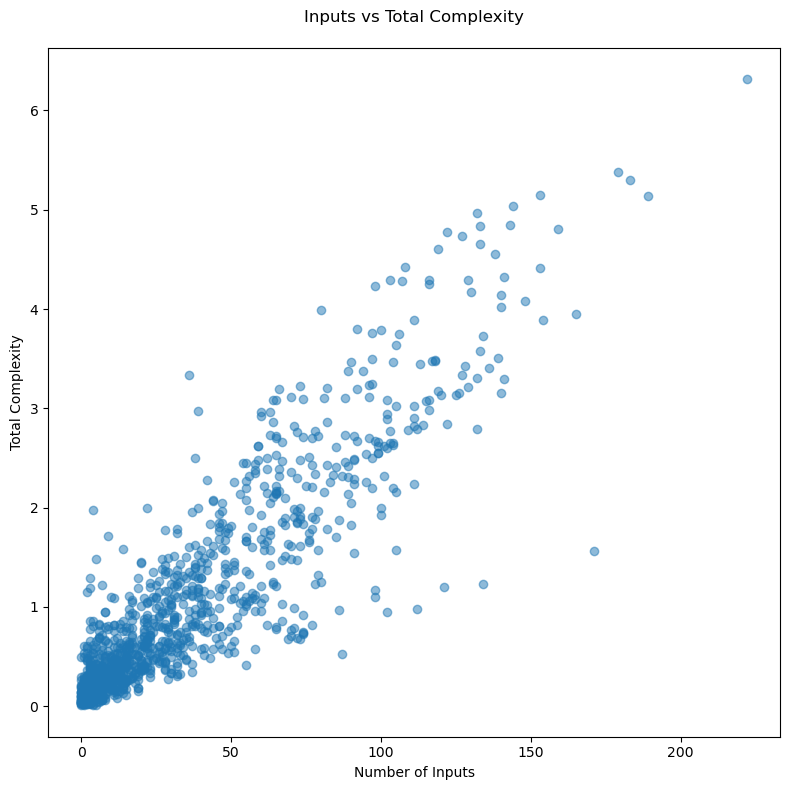

In [17]:
C = pd.read_parquet(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\data\HS22_2022_4_digits\AIPNET\C_4_digits_HS22.parquet"
).values

n_inputs = (
    C > 0
).sum(axis=0)

df["n_inputs"]=n_inputs
pearson = pearsonr(
    df["n_inputs"],
    df["total_complexity"]
)[0]
plt.figure(figsize=(8,8))

plt.scatter(
    df["n_inputs"],
    df["total_complexity"],
    alpha=0.5
)

plt.xlabel(
    "Number of Inputs"
)

plt.ylabel(
    "Total Complexity"
)

plt.title(
    f"Inputs vs Total Complexity\n"
    
)
print(f"Pearson={pearson:.3f}")
plt.tight_layout()
plt.savefig(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots\input_vs_total_complexity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Input count vs rank total

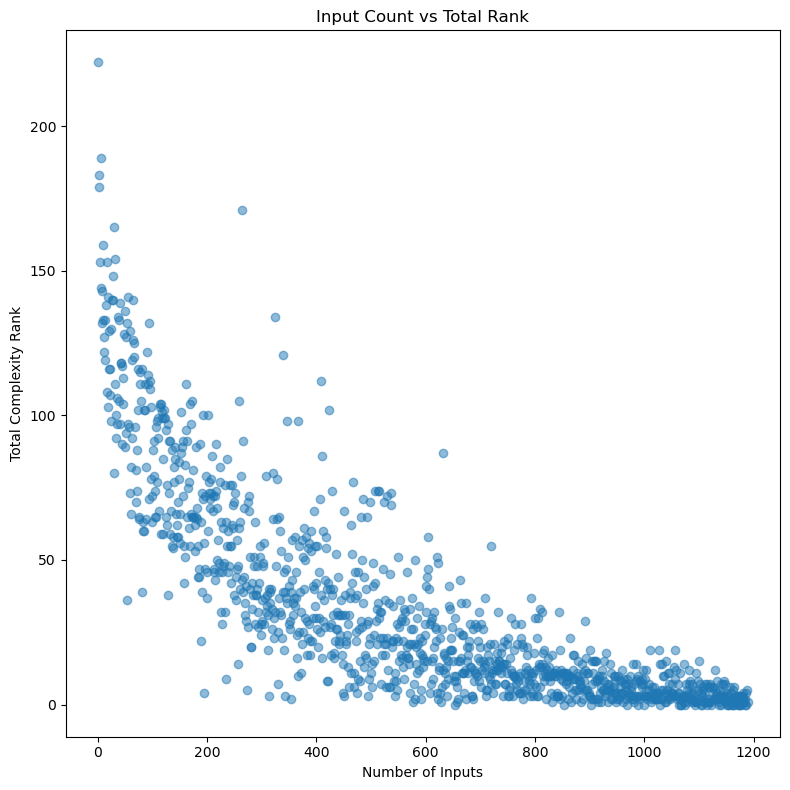

In [18]:
df["rank_total"] = (
    df["total_complexity"]
    .rank(ascending=False)
)
plt.figure(figsize=(8,8))

plt.scatter(
    df["rank_total"],
    df["n_inputs"],
    alpha=0.5
)

plt.xlabel(
    "Number of Inputs"
)

plt.ylabel(
    "Total Complexity Rank"
)

plt.title(
    "Input Count vs Total Rank"
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots\input_vs_total_complexity_rank.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Intrinsic complexity

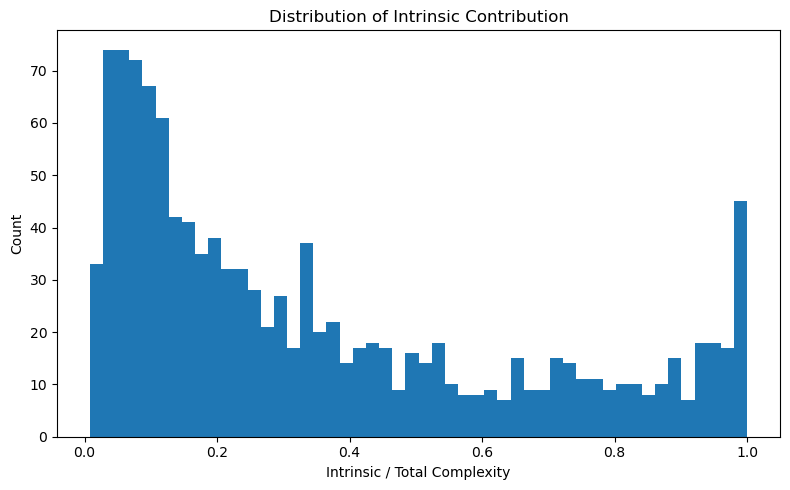

In [19]:
df["intrinsic_share"] = (
    df["intrinsic_complexity"]
    / df["total_complexity"]
)

plt.figure(figsize=(8,5))

plt.hist(
    df["intrinsic_share"],
    bins=50
)

plt.xlabel(
    "Intrinsic / Total Complexity"
)

plt.ylabel("Count")

plt.title(
    "Distribution of Intrinsic Contribution"
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots\intrinsic_complexity_contribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 4) STUDIO DI CONVERGENZA

Per fare lo studio di convergenza devo runnare l' algoritmo di nuovo 

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.algorithms import run_fitness_tracked, run_modified_fitness_tracked
from src.operators import theta_1, phi_1, phi_2

In [9]:
# ── Dati (2022 HS4) ─────────────────────────────────────────────────────────────────────

Mcp_export = pd.read_parquet(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\data\HS22_2022_4_digits"
    r"\Mcp\Mcp_export\Mcp_export_2022_filtered.parquet"
)
Mcp_import = pd.read_parquet(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\data\HS22_2022_4_digits\Mcp\Mcp_import\Mcp_import_2022_filtered.parquet"
     # <-- aggiusta path
)
C = pd.read_parquet(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\data\HS22_2022_4_digits\AIPNET\C_4_digits_HS22.parquet")
C = C.T   # prodotti sulle righe → input nelle righe

In [ ]:
# ── Run algoritmi ───────────────────────────────────────────────
print("Running fitness...")
hist_1, steps_1 = compute_fitness(Mcp_export)

print("Running extended_fitness...")
hist_2, steps_2 = compute_extended_fitness(Mcp_export, C, phi=phi_1, theta=theta_1)

print(f"Fitness      → convergenza in {steps_1} iterazioni")
print(f"Extended Fitness      → convergenza in {steps_2} iterazioni")

Running compute_fitness...
Running compute_modified_fitness_1...
Fitness base      → convergenza in 149 iterazioni
Fitness modificata → convergenza in 25 iterazioni


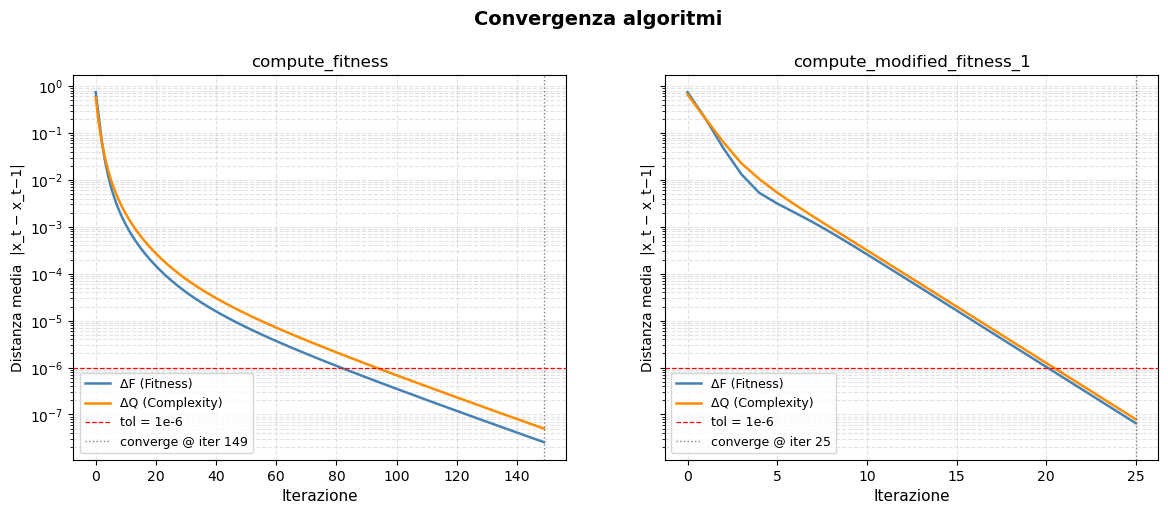

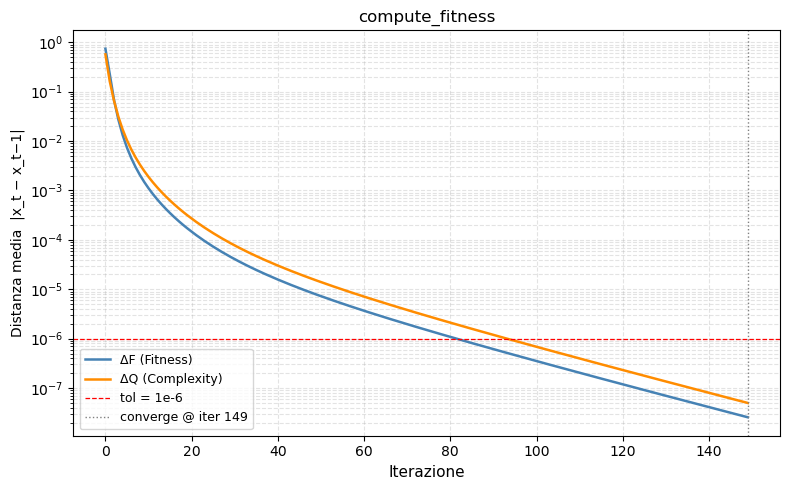

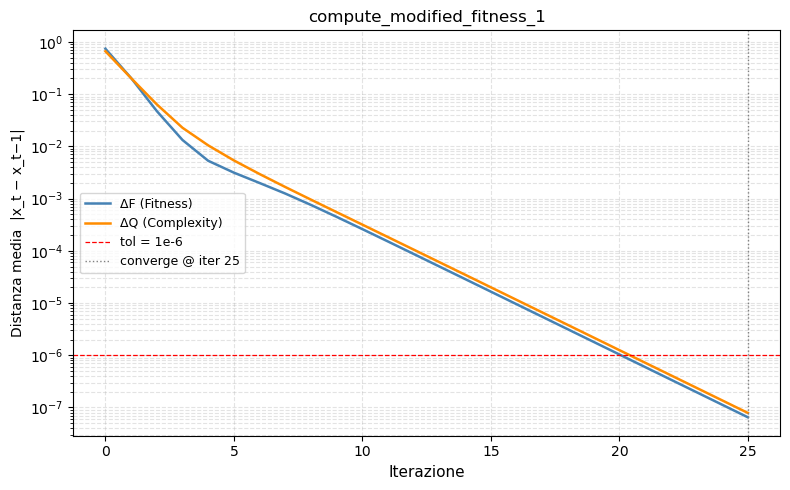

In [11]:
# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Convergenza algoritmi", fontsize=14, fontweight="bold", y=1.01)

configs = [
    (hist_1, steps_1, "compute_fitness",           axes[0]),
    (hist_2, steps_2, "compute_modified_fitness_1", axes[1]),
]

for hist, steps, title, ax in configs:
    ax.plot(hist[:, 0], label="ΔF (Fitness)",     color="steelblue",  linewidth=1.8)
    ax.plot(hist[:, 1], label="ΔQ (Complexity)",  color="darkorange", linewidth=1.8)
    ax.axhline(1e-6, color="red", linestyle="--", linewidth=0.9, label="tol = 1e-6")
    ax.axvline(steps, color="gray", linestyle=":", linewidth=1.0, label=f"converge @ iter {steps}")
    ax.set_yscale("log")
    ax.set_xlabel("Iterazione", fontsize=11)
    ax.set_ylabel("Distanza media  |x_t − x_t−1|", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, which="both", linestyle="--", alpha=0.35)

for hist, steps, title, ax in configs:
    fig_single, ax_single = plt.subplots(figsize=(8, 5))
    ax_single.plot(hist[:, 0], label="ΔF (Fitness)",    color="steelblue",  linewidth=1.8)
    ax_single.plot(hist[:, 1], label="ΔQ (Complexity)", color="darkorange", linewidth=1.8)
    ax_single.axhline(1e-6, color="red",  linestyle="--", linewidth=0.9, label="tol = 1e-6")
    ax_single.axvline(steps, color="gray", linestyle=":", linewidth=1.0, label=f"converge @ iter {steps}")
    ax_single.set_yscale("log")
    ax_single.set_xlabel("Iterazione", fontsize=11)
    ax_single.set_ylabel("Distanza media  |x_t − x_t−1|", fontsize=10)
    ax_single.set_title(title, fontsize=12)
    ax_single.legend(fontsize=9)
    ax_single.grid(True, which="both", linestyle="--", alpha=0.35)
    fig_single.tight_layout()
    save_dir = Path(r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots")
    save_dir.mkdir(parents=True, exist_ok=True)
    fig_single.savefig(save_dir / f"convergenza_{title}.png", dpi=180, bbox_inches="tight")
    plt.show()

### 4) Q medio in funzione dello step

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspecimport 
import numpy as np
import pandas as pd
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.algorithms import run_extended_fitness_tracked
from src.operators import theta_1, phi_1, phi_2

In [3]:
# ── Dati ─────────────────────────────────────────────────────────────────────

Mcp_export = pd.read_parquet(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\data\HS22_2022_4_digits"
    r"\Mcp\Mcp_export\Mcp_export_2022_filtered.parquet"
)
Mcp_import = pd.read_parquet(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\data\HS22_2022_4_digits\Mcp\Mcp_import\Mcp_import_2022_filtered.parquet"
     # <-- aggiusta path
)
C = pd.read_parquet(
    r"C:\Users\vitto\Desktop\CSH RESEARCH\data\HS22_2022_4_digits\AIPNET\C_4_digits_HS22.parquet")
C = C.T   # prodotti sulle righe → input nelle righe

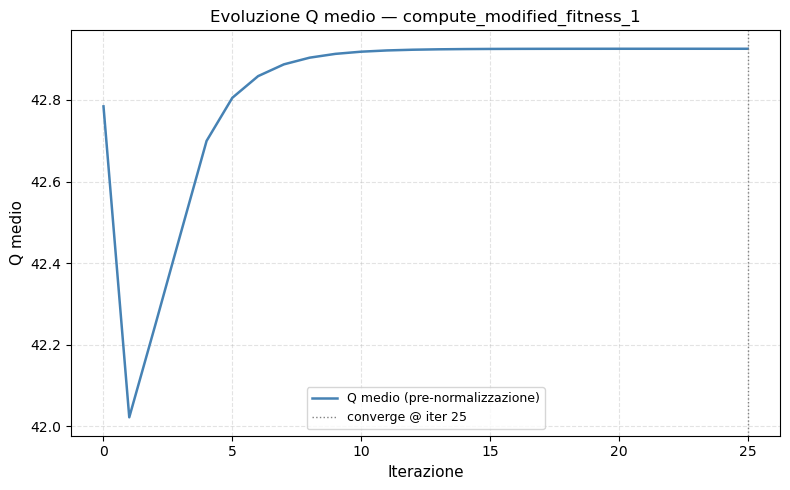

In [5]:
hist_2, Q_average, steps_2 = run_extended_fitness_tracked(
    Mcp_export, C, phi=phi_1, theta=theta_1, max_iter=1000, tol=1e-6
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Q_average, color="steelblue", linewidth=1.8, label="Q medio (pre-normalizzazione)")
ax.axvline(steps_2, color="gray", linestyle=":", linewidth=1.0, label=f"converge @ iter {steps_2}")
ax.set_xlabel("Iterazione", fontsize=11)
ax.set_ylabel("Q medio", fontsize=11)
ax.set_title("Evoluzione Q medio — compute_modified_fitness_1", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.35)
fig.tight_layout()

save_dir = Path(r"C:\Users\vitto\Desktop\CSH RESEARCH\results\real_data\2022_hs22_4_digits\plots")
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / "Q_medio_evolution.png", dpi=180, bbox_inches="tight")
plt.show()